# Fraud_Credit_Card

# EDA

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [6]:
import pandas as pd
# from pandas_profiling import ProfileReport

In [7]:
df = pd.read_csv("C:/Users/eitank/Documents/personal/Projects/Fraud_Credit_Card/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

No categorical/string columns are included (Only the target variable is categorical). No NULL values. All columns except for Time and Amount are transformed by PCA and have been Scaled.

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


492 Of Frauds 0.17%
284315 No Frauds 99.83%


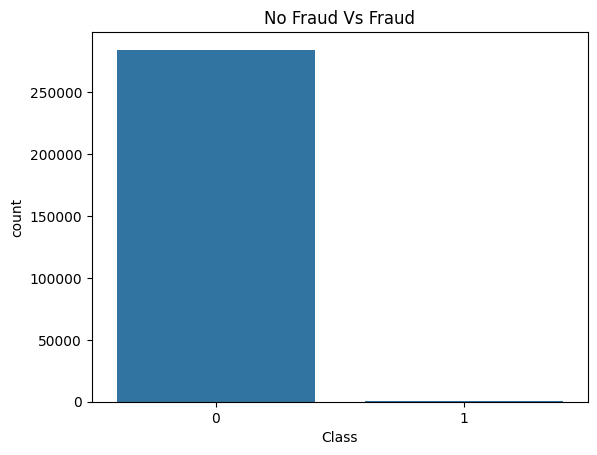

In [10]:
fraud=len(df[df["Class"]==1])
no_fraud=len(df[df["Class"]==0])
total =len(df)
print(f"{fraud} Of Frauds {round(fraud/total* 100,2)}%")
print(f"{no_fraud} No Frauds {round(no_fraud/total* 100,2)}%")
sns.countplot(data=df,x="Class")
plt.title("No Fraud Vs Fraud")
plt.show()

As you can see, there is only 0.17% fraud , which is a severe imbalance. 

In [11]:
# design_report = ProfileReport(df)
# design_report.to_file(output_file='credit_card.html')

In [12]:
# import sweetviz as sv

In [13]:
# sweet_report = sv.analyze(df)
# sweet_report.show_html('credit_card_sr.html')

Heatmap to Visualize the Correlation Between Numerical Features

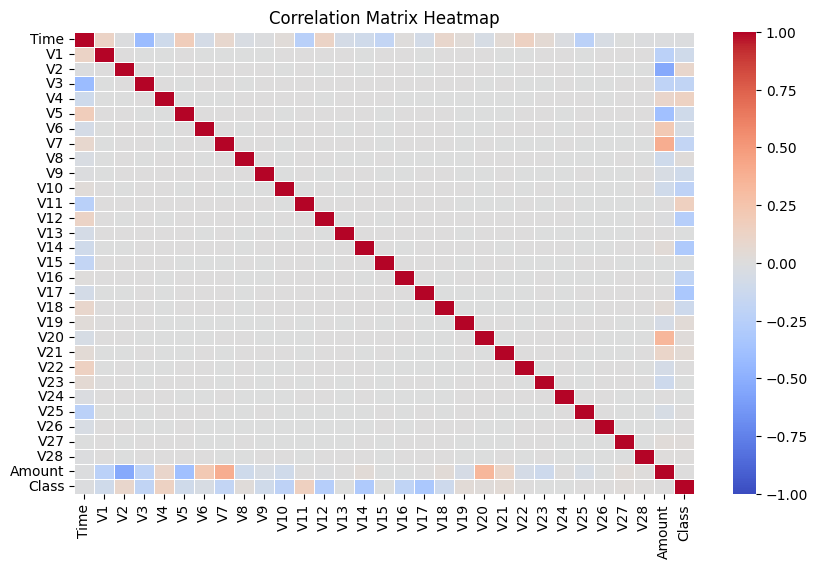

In [14]:
correlation_matrix=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,cmap='coolwarm',vmin=-1,vmax=1,annot=False,linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Interaction with other variables (Non- traget variable):

Baded on reports and the above heatmap there is no notable correlation between features V1-V28. 

There are certain correlations between some of these features and Time (inverse correlation with V3)
Amount (direct correlation with V7,V6 and V20, inverse correlation with V2 and V5).

The hour with the most frequent fraud is: 2.0:00
Number of fraud during this hour: 57


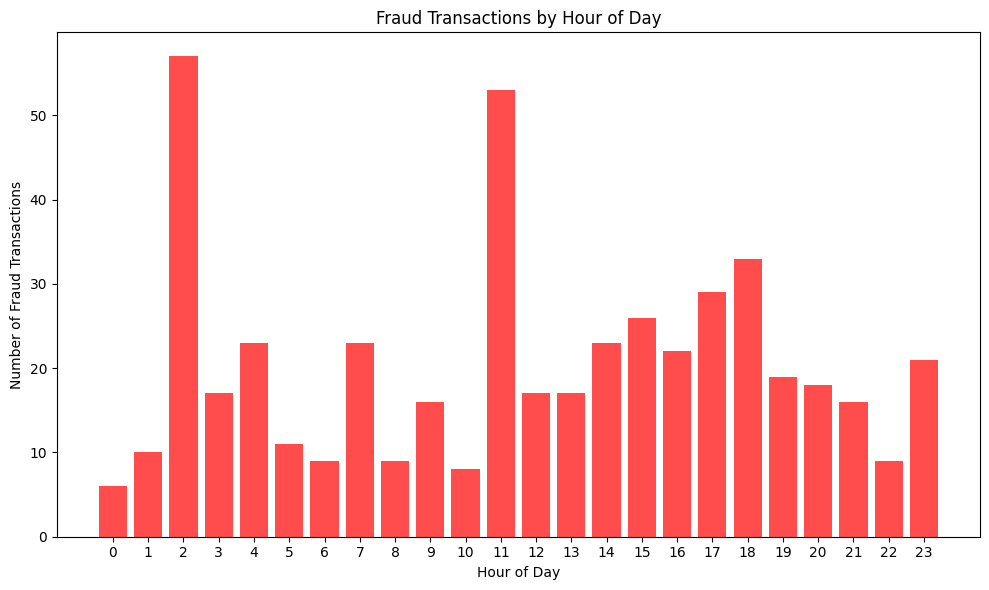

In [15]:
# Convert the 'Time' column to hours
df['hour_of_day'] = (df['Time'] // 3600) % 24

# Assuming 'Class' column indicates fraud transactions (1 for fraud, 0 for non-fraud)
df['is_fraud'] = df['Class']

# Separate the fraud transactions
fraud_df = df[df['is_fraud'] == 1]

# Aggregate by hour for fraud transactions
fraud_by_hour = fraud_df.groupby('hour_of_day').size()

# Find the hour with the most frequent fraud transactions
most_frequent_hour = fraud_by_hour.idxmax()
most_frequent_count = fraud_by_hour.max()

# Print the result
print(f"The hour with the most frequent fraud is: {most_frequent_hour}:00")
print(f"Number of fraud during this hour: {most_frequent_count}")

# Plotting the distribution of fraudulent transactions by hour
plt.figure(figsize=(10, 6))
plt.bar(fraud_by_hour.index, fraud_by_hour.values, color='red', alpha=0.7)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraud Transactions')
plt.title('Fraud Transactions by Hour of Day')
plt.xticks(range(0, 24))  # Set x-ticks for hours
plt.tight_layout()
plt.show()


The following bar plot visually represents the distribution of fraudulent transactions by hour of the day. The peak at 2:00 AM indicates the highest frequency of fraudulent activities during this time.This analysis highlights the importance of monitoring specific hours of the day for potential fraudulent activities. By focusing on peak hours, such as 2:00 AM, institutions can enhance their fraud detection mechanisms and prevent potential losses.

In [16]:
# Separate fraudulent and non-fraudulent transactions
fraudulent_df = df[df['Class'] == 1]
non_fraudulent_df = df[df['Class'] == 0]

# Calculate required statistics for fraudulent transactions
fraudulent_stats = fraudulent_df.groupby('hour_of_day').agg({
    'Amount': ['sum', 'mean', 'min', 'max', 'median']
}).reset_index()
fraudulent_stats.columns = ['Hour', 'Total', 'Mean', 'Min', 'Max', 'Median']

# Calculate required statistics for non-fraudulent transactions
non_fraudulent_stats = non_fraudulent_df.groupby('hour_of_day').agg({
    'Amount': ['sum', 'mean', 'min', 'max', 'median']
}).reset_index()
non_fraudulent_stats.columns = ['Hour', 'Total', 'Mean', 'Min', 'Max', 'Median']

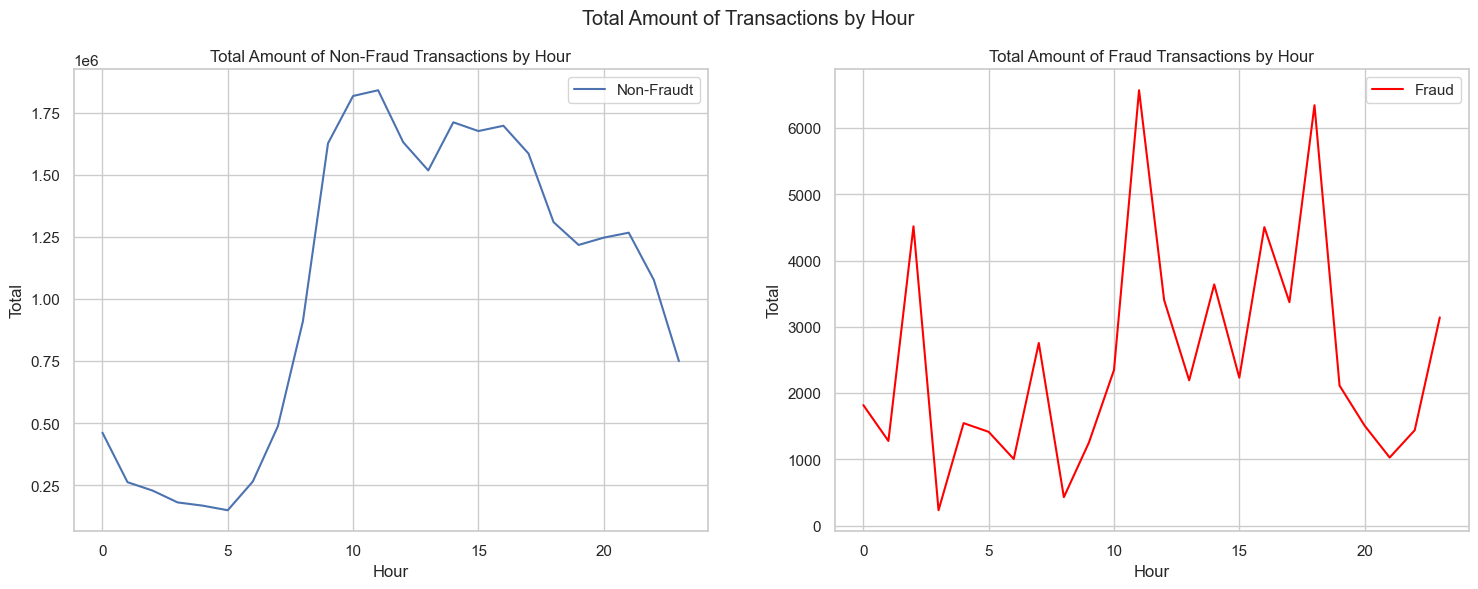

In [17]:
# Set up the plotting environment
sns.set(style="whitegrid")

# Plot Total Amount
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18, 6))
sns.lineplot(ax=ax1, x='Hour', y='Total', data=non_fraudulent_stats, label='Non-Fraudt')
sns.lineplot(ax=ax2, x='Hour', y='Total', data=fraudulent_stats, label='Fraud', color='red')
ax1.set_title('Total Amount of Non-Fraud Transactions by Hour')
ax2.set_title('Total Amount of Fraud Transactions by Hour')
plt.suptitle('Total Amount of Transactions by Hour')
plt.show()
df=df.drop(columns=['is_fraud','hour_of_day'])


In this section, we visualize Total of transaction amounts by the hour for both fraudulent and non-fraudulent transactions. This helps us understand the temporal patterns and differences between fraudulent and non-fraudulent transactions.

In [18]:
# Duplicating Data (Number of Columns)

print(f"Non-Frauds: {df[df.Class == 0].duplicated().sum()}")
print(f"Frauds: {df[df.Class == 1].duplicated().sum()}")
print("*" * 100)

# Drop
df.drop_duplicates(inplace=True)
print("Dropped Succesfully")
print("*" * 100)

# Check
print(f"Non-Frauds: {df[df.Class == 0].duplicated().sum()}")
print(f"Frauds: {df[df.Class == 1].duplicated().sum()}")

Non-Frauds: 1062
Frauds: 19
****************************************************************************************************
Dropped Succesfully
****************************************************************************************************
Non-Frauds: 0
Frauds: 0


Check again the percentage between Fraud and non

473 Of Frauds 0.17%
283253 No Frauds 99.83%


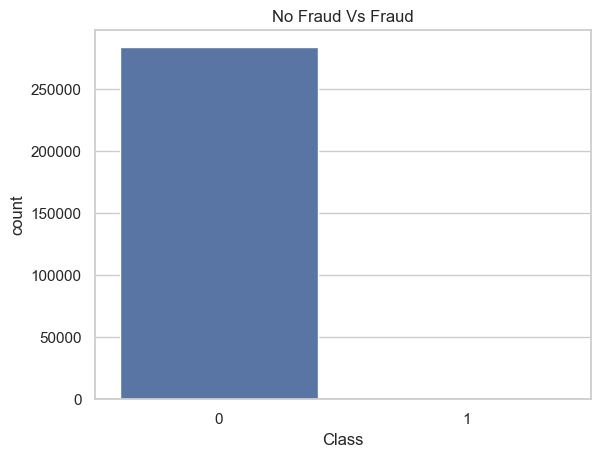

In [19]:
fraud=len(df[df["Class"]==1])
no_fraud=len(df[df["Class"]==0])
total =len(df)
print(f"{fraud} Of Frauds {round(fraud/total* 100,2)}%")
print(f"{no_fraud} No Frauds {round(no_fraud/total* 100,2)}%")
sns.countplot(data=df,x="Class")
plt.title("No Fraud Vs Fraud")
plt.show()

Missing- None.

Outliers -  I'll not deal with them. Becuase all is possible. The amount for example could be easily over 5k.

📌 Columns with outliers and the number of outliers in each:
V1: 6948 outliers
V2: 13390 outliers
V3: 3306 outliers
V4: 11094 outliers
V5: 12221 outliers
V6: 22886 outliers
V7: 8839 outliers
V8: 23904 outliers
V9: 8199 outliers
V10: 9345 outliers
V11: 735 outliers
V12: 15282 outliers
V13: 3362 outliers
V14: 14060 outliers
V15: 2884 outliers
V16: 8180 outliers
V17: 7353 outliers
V18: 7468 outliers
V19: 10150 outliers
V20: 27553 outliers
V21: 14401 outliers
V22: 1298 outliers
V23: 18467 outliers
V24: 4758 outliers
V25: 5333 outliers
V26: 5665 outliers
V27: 38799 outliers
V28: 30094 outliers
Amount: 31685 outliers
Class: 473 outliers


C:\Users\eitank\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


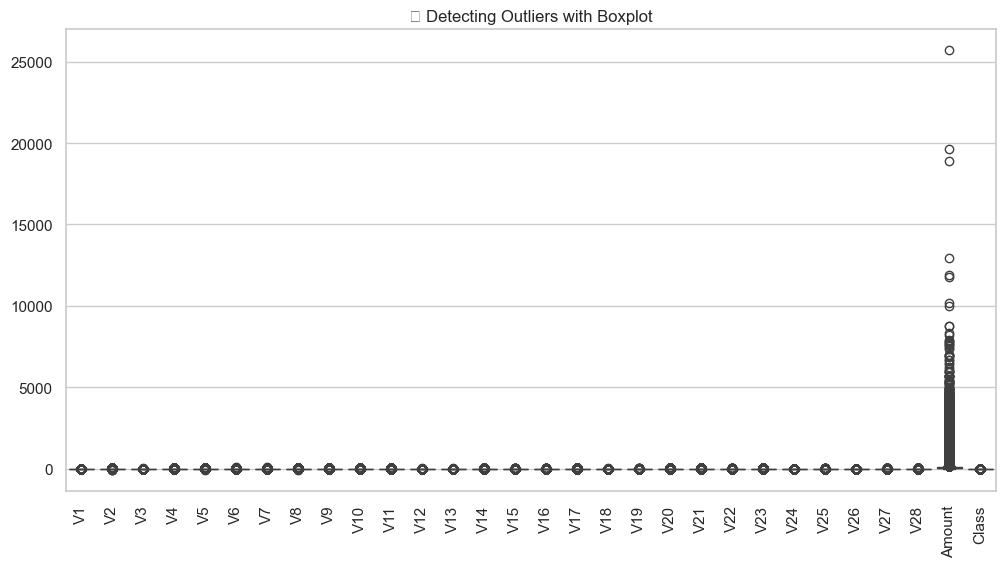

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Detect outliers in each numerical column using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers.shape[0]

# 2️⃣ Check for outliers in all numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
outlier_counts = {col: detect_outliers(df, col) for col in num_cols}

# 3️⃣ Print columns with outliers and their count
outlier_cols = {col: count for col, count in outlier_counts.items() if count > 0}
print("📌 Columns with outliers and the number of outliers in each:")
for col, count in outlier_cols.items():
    print(f"{col}: {count} outliers")

# 4️⃣ Display Boxplot for all columns with outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[list(outlier_cols.keys())])
plt.xticks(rotation=90)
plt.title("🔍 Detecting Outliers with Boxplot")
plt.show()
